##### Stock price prediction on one year of NVIDIA prices 

CSV data downloaded from Yahoo Finance: https://www.nasdaq.com/market-activity/stocks/nvda/historical
Time Period: 10yr

##### Cleaning the CSV data, sort in reverse order

In [1]:
import pandas as pd
import aboodutils
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


df = pd.read_csv("../../HistoricalData_1749770593630.csv")

df[df.columns[1:]] = df[df.columns[1:]].replace('[\$,]', '', regex=True).astype(float)

df = df.iloc[::-1]

df.reset_index(drop=True, inplace=True)

df.tail()


/home/abood/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


,Date,Close/Last,Volume,Open,High,Low
2510,06/05/2025,139.99,232410800.0,142.17,144.00,138.830
2511,06/06/2025,141.72,153986200.0,142.51,143.27,141.510
2512,06/09/2025,142.63,185114500.0,143.19,145.00,141.940
2513,06/10/2025,143.96,155881900.0,142.69,144.29,141.525
2514,06/11/2025,142.83,167694000.0,144.61,144.99,141.870


### Plot initial data after cleaning

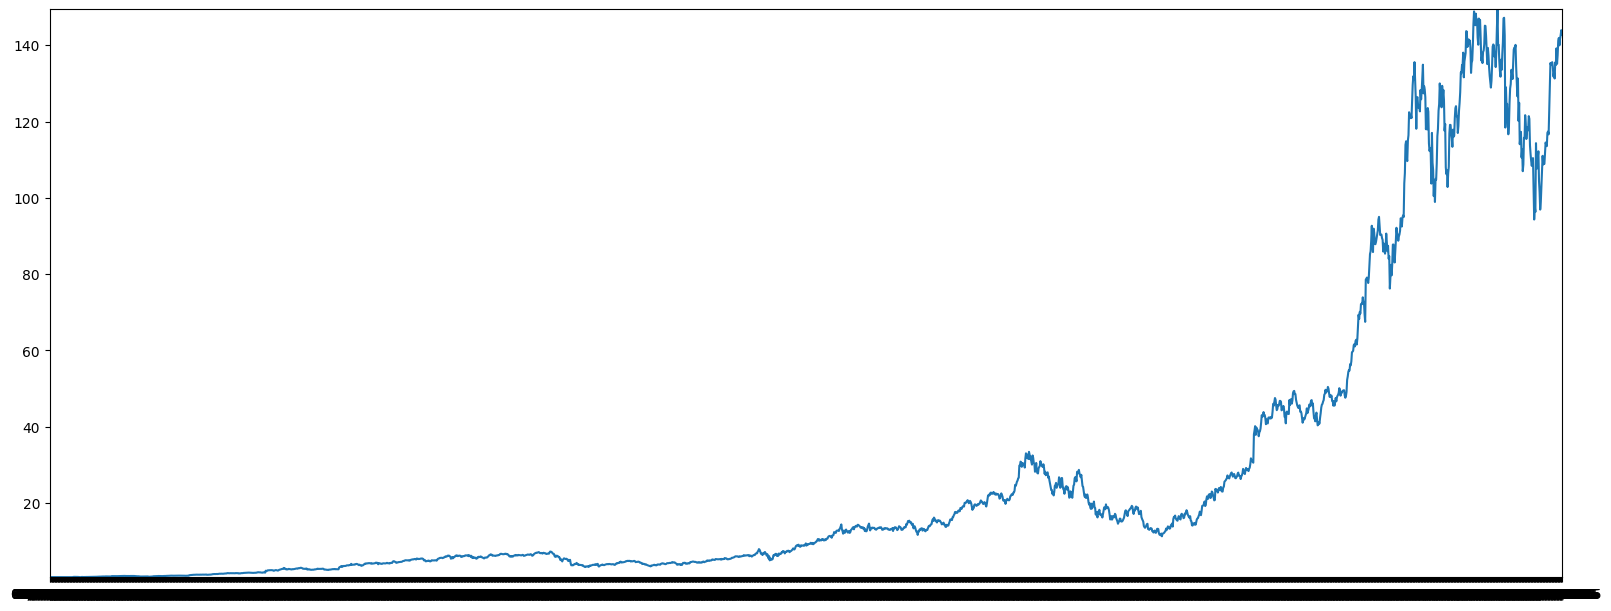

In [2]:
plotdf = df.drop(["Volume", "Open", "High", "Low"], axis=1)

fig, ax = plt.subplots(layout="constrained")
fig.set_size_inches(16, 6)
ax.autoscale(enable=True, axis='both', tight=True)

ax.plot(plotdf["Date"], plotdf["Close/Last"])


#### Plot the sanitized data

In [3]:
y = df["Close/Last"]
X = df.drop(columns=["Date", "Close/Last"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgbr = XGBRegressor(verbosity=0)

xgbr.fit(X_train, y_train)

y_pred = xgbr.predict(X_test)

ax.plot(y_pred)

#### Plot forecast

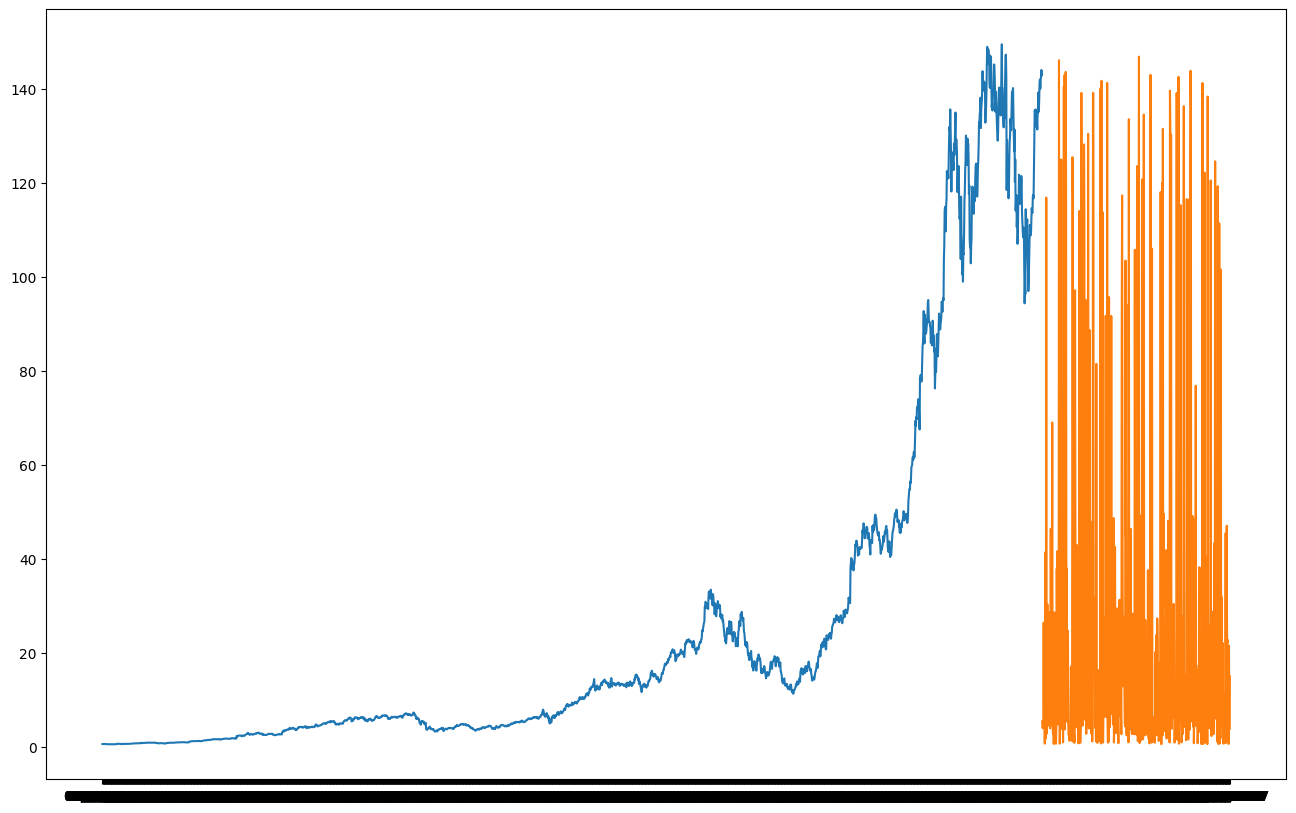

In [4]:
periods = len(y_pred)
fut_range = pd.date_range("2025-06-12", periods=periods, freq="B")

pred_df = pd.DataFrame({"Date": fut_range, "Close/Last": y_pred})

pred_df["Date"] = pred_df["Date"].dt.strftime('%m/%d/%Y')

plt.figure(figsize=(16, 10))
plt.plot(plotdf["Date"], plotdf["Close/Last"])
plt.plot(pred_df["Date"], pred_df["Close/Last"])
